In [27]:
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split



In [28]:
df = pd.read_csv('bmw.csv')

print(df.head())


       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  


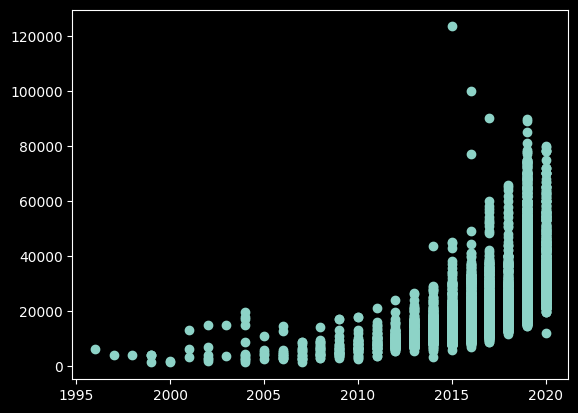

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df.year, df.price)
plt.show()

In [30]:
from sklearn.linear_model import LinearRegression

bmw_year = LinearRegression()
bmw_year.fit(df[['year', 'mileage', 'tax', 'mpg', 'engineSize' ]], df['price'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
print(bmw_year.coef_)
print(bmw_year.intercept_)

[ 2.05517013e+03 -1.27541981e-01  3.04283771e+00  2.16419510e+01
  1.00771754e+04]
-4142921.3349490557


46264837.98100205
4630.70819278408


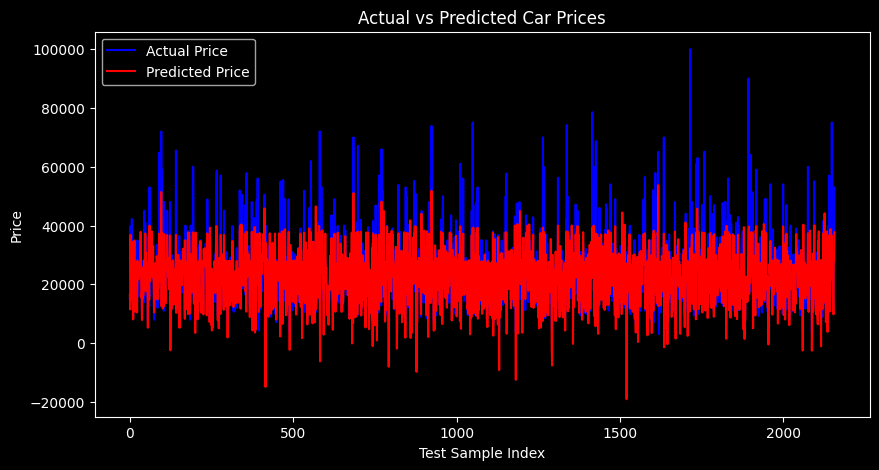

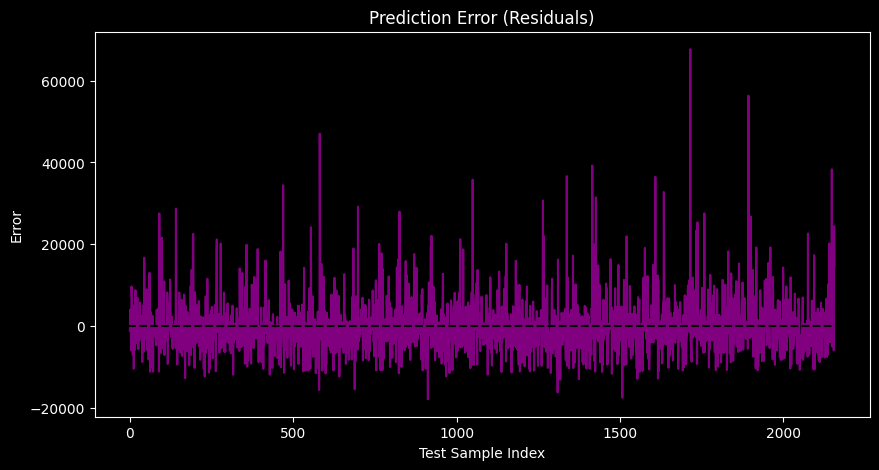

In [32]:
x = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(mse)
print(mae)

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Price", color="blue")
plt.plot(y_pred, label="Predicted Price", color="red")

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Test Sample Index")
plt.ylabel("Price")
plt.legend()

errors = y_test.values - y_pred

plt.figure(figsize=(10,5))

plt.plot(errors, color="purple")
plt.axhline(y=0, color='black', linestyle='--')

plt.title("Prediction Error (Residuals)")
plt.xlabel("Test Sample Index")
plt.ylabel("Error")

plt.show()

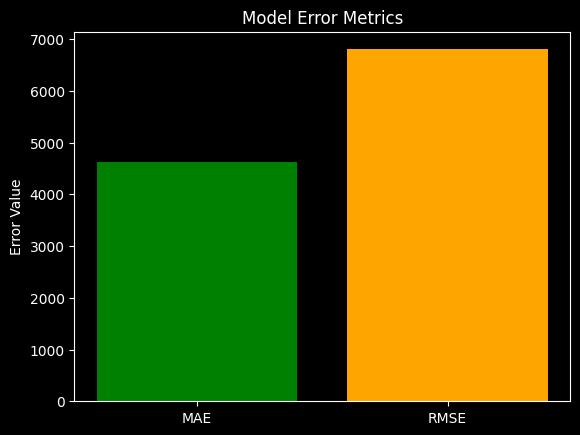

In [33]:
import numpy as np

rmse = np.sqrt(mse)

metrics = ['MAE', 'RMSE']
values = [mae, rmse]

plt.bar(metrics, values, color=['green', 'orange'])

plt.title("Model Error Metrics")
plt.ylabel("Error Value")

plt.show()

In [34]:
print(bmw_year.predict([[2025, 4500, 135, 54.3, 3.5]]))


[55080.29171144]


C:\Users\mandi\AppData\Local\Altair\MF\envs\py_tf\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
